In [11]:
!pip install kagglehub xgboost lightgbm shap -q

import kagglehub
import os, glob, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import pickle

In [12]:
# Use the official Backblaze dataset - most reliable source
path_bb = kagglehub.dataset_download("backblaze/hard-drive-test-data")
print("Downloaded to:", path_bb)

csv_files_bb = glob.glob(os.path.join(path_bb, "**/*.csv"), recursive=True)
print(f"Total files: {len(csv_files_bb)}")

for f in csv_files_bb[:10]:
    print(f)

Downloaded to: /kaggle/input/datasets/organizations/backblaze/hard-drive-test-data
Total files: 1
/kaggle/input/datasets/organizations/backblaze/hard-drive-test-data/harddrive.csv


In [13]:
csv_path = csv_files_bb[0]

sample_df = pd.read_csv(
    csv_path,
    nrows=5
)

print("Shape:", sample_df.shape)

print("\nColumns:\n")
print(sample_df.columns.tolist())

sample_df.head()

Shape: (5, 95)

Columns:

['date', 'serial_number', 'model', 'capacity_bytes', 'failure', 'smart_1_normalized', 'smart_1_raw', 'smart_2_normalized', 'smart_2_raw', 'smart_3_normalized', 'smart_3_raw', 'smart_4_normalized', 'smart_4_raw', 'smart_5_normalized', 'smart_5_raw', 'smart_7_normalized', 'smart_7_raw', 'smart_8_normalized', 'smart_8_raw', 'smart_9_normalized', 'smart_9_raw', 'smart_10_normalized', 'smart_10_raw', 'smart_11_normalized', 'smart_11_raw', 'smart_12_normalized', 'smart_12_raw', 'smart_13_normalized', 'smart_13_raw', 'smart_15_normalized', 'smart_15_raw', 'smart_22_normalized', 'smart_22_raw', 'smart_183_normalized', 'smart_183_raw', 'smart_184_normalized', 'smart_184_raw', 'smart_187_normalized', 'smart_187_raw', 'smart_188_normalized', 'smart_188_raw', 'smart_189_normalized', 'smart_189_raw', 'smart_190_normalized', 'smart_190_raw', 'smart_191_normalized', 'smart_191_raw', 'smart_192_normalized', 'smart_192_raw', 'smart_193_normalized', 'smart_193_raw', 'smart_194_

,date,serial_number,model,capacity_bytes,failure,smart_1_normalized,smart_1_raw,smart_2_normalized,smart_2_raw,smart_3_normalized,...,smart_250_normalized,smart_250_raw,smart_251_normalized,smart_251_raw,smart_252_normalized,smart_252_raw,smart_254_normalized,smart_254_raw,smart_255_normalized,smart_255_raw
0,2016-01-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,135.0,108.0,143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01,Z305B2QN,ST4000DM000,1.976651e-311,0,113,54551400,NaN,NaN,96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01,MJ0351YNG9Z7LA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,136.0,104.0,124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-01,MJ0351YNGABYAA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,136.0,104.0,137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-01,WD-WMC4N2899475,WDC WD30EFRX,1.482490e-311,0,200,0,NaN,NaN,175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
use_cols = [
    "date", "serial_number", "model", "failure",

    # Key SMART raw metrics
    "smart_1_raw",
    "smart_5_raw",
    "smart_9_raw",
    "smart_187_raw",
    "smart_188_raw",
    "smart_189_raw",
    "smart_190_raw",
    "smart_194_raw",
    "smart_197_raw",
    "smart_198_raw",
    "smart_199_raw",
    "smart_241_raw",
    "smart_242_raw",
]

df = pd.read_csv(csv_path, usecols=use_cols)

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Failures:", df["failure"].sum())
print("Failure rate %:", df["failure"].mean() * 100)

df.head()

Rows: 3179295
Columns: 17
Failures: 215
Failure rate %: 0.006762505524023407


,date,serial_number,model,failure,smart_1_raw,smart_5_raw,smart_9_raw,smart_187_raw,smart_188_raw,smart_189_raw,smart_190_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_241_raw,smart_242_raw
0,2016-01-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,0,0,0,27929,NaN,0.0,NaN,NaN,20.0,0,0,0,0.000000e+00,0.000000e+00
1,2016-01-01,Z305B2QN,ST4000DM000,0,54551400,0,411,0.0,0.0,0.0,30.0,30.0,0,0,0,3.467963e-315,1.316882e-315
2,2016-01-01,MJ0351YNG9Z7LA,Hitachi HDS5C3030ALA630,0,0,0,27492,NaN,0.0,NaN,NaN,24.0,0,0,0,0.000000e+00,0.000000e+00
3,2016-01-01,MJ0351YNGABYAA,Hitachi HDS5C3030ALA630,0,0,0,26640,NaN,0.0,NaN,NaN,31.0,0,0,0,0.000000e+00,0.000000e+00
4,2016-01-01,WD-WMC4N2899475,WDC WD30EFRX,0,0,0,12198,NaN,0.0,NaN,NaN,29.0,0,0,0,0.000000e+00,0.000000e+00


In [15]:
df["date"] = pd.to_datetime(df["date"])

smart_cols = [c for c in df.columns if c.startswith("smart_")]

df[smart_cols] = df[smart_cols].fillna(0)

df = df.sort_values(["serial_number", "date"]).reset_index(drop=True)

print("Date range:", df["date"].min(), "to", df["date"].max())
print("Unique drives:", df["serial_number"].nunique())
print("SMART columns:", smart_cols)

Date range: 2016-01-01 00:00:00 to 2016-04-29 00:00:00
Unique drives: 65993
SMART columns: ['smart_1_raw', 'smart_5_raw', 'smart_9_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_241_raw', 'smart_242_raw']


In [16]:
failed_drives = df[df["failure"] == 1]["serial_number"].nunique()
total_drives = df["serial_number"].nunique()

print("Total drives:", total_drives)
print("Failed drives:", failed_drives)
print("Healthy drives:", total_drives - failed_drives)

df["failure"].value_counts()

Total drives: 65993
Failed drives: 205
Healthy drives: 65788


failure
0    3179080
1        215
Name: count, dtype: int64

In [17]:
def create_future_failure_labels(group):

    group = group.sort_values("date").copy()

    group["failure_30d"] = 0

    failure_dates = group.loc[
        group["failure"] == 1,
        "date"
    ]

    if len(failure_dates) == 0:
        return group

    for fail_date in failure_dates:

        mask = (
            (group["date"] >= fail_date - pd.Timedelta(days=30))
            &
            (group["date"] <= fail_date)
        )

        group.loc[mask, "failure_30d"] = 1

    return group


df = (
    df.groupby("serial_number", group_keys=False)
      .apply(create_future_failure_labels)
)

print(df["failure_30d"].value_counts())

failure_30d
0    3176335
1       2960
Name: count, dtype: int64


In [18]:
print("Original failures:")
print(df["failure"].sum())

print("\n30-day failures:")
print(df["failure_30d"].sum())

print("\nPositive rate:")
print(
    round(
        df["failure_30d"].mean()*100,
        4
    ),
    "%"
)

Original failures:
215

30-day failures:
2960

Positive rate:
0.0931 %


In [19]:
# Cell 9 - Strong Feature Engineering

base_features = [
    "smart_1_raw",
    "smart_5_raw",
    "smart_9_raw",
    "smart_187_raw",
    "smart_188_raw",
    "smart_189_raw",
    "smart_190_raw",
    "smart_194_raw",
    "smart_197_raw",
    "smart_198_raw",
    "smart_199_raw",
    "smart_241_raw",
    "smart_242_raw",
]

# make sure sorted
df = df.sort_values(["serial_number", "date"]).reset_index(drop=True)

# Drive age
df["drive_age_days"] = df.groupby("serial_number").cumcount()

for col in base_features:
    # 7-day rolling average
    df[f"{col}_7d_avg"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(7, min_periods=1).mean())
    )

    # 7-day rolling max
    df[f"{col}_7d_max"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(7, min_periods=1).max())
    )

    # 7-day rolling std
    df[f"{col}_7d_std"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(7, min_periods=1).std())
    )

    # 14-day rolling average
    df[f"{col}_14d_avg"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(14, min_periods=1).mean())
    )

    # 14-day rolling std
    df[f"{col}_14d_std"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(14, min_periods=1).std())
    )

    # difference from 7 days ago
    df[f"{col}_7d_diff"] = (
        df.groupby("serial_number")[col]
        .diff(7)
    )

    # percentage change
    df[f"{col}_pct_change"] = (
        df.groupby("serial_number")[col]
        .pct_change()
        .replace([np.inf, -np.inf], 0)
    )

df = df.replace([np.inf, -np.inf], 0)
df = df.fillna(0)

print("Feature engineering completed.")
print("Rows:", len(df))
print("Columns now:", df.shape[1])

Feature engineering completed.
Rows: 3179295
Columns now: 110


In [20]:
# Cell 10 - Final Feature List

drop_cols = [
    "date",
    "serial_number",
    "model",
    "failure",
    "failure_30d"
]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols
]

print("Total features:", len(feature_cols))
print(feature_cols[:30])

Total features: 105
['smart_1_raw', 'smart_5_raw', 'smart_9_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_241_raw', 'smart_242_raw', 'drive_age_days', 'smart_1_raw_7d_avg', 'smart_1_raw_7d_max', 'smart_1_raw_7d_std', 'smart_1_raw_14d_avg', 'smart_1_raw_14d_std', 'smart_1_raw_7d_diff', 'smart_1_raw_pct_change', 'smart_5_raw_7d_avg', 'smart_5_raw_7d_max', 'smart_5_raw_7d_std', 'smart_5_raw_14d_avg', 'smart_5_raw_14d_std', 'smart_5_raw_7d_diff', 'smart_5_raw_pct_change', 'smart_9_raw_7d_avg', 'smart_9_raw_7d_max']


In [21]:
# Cell 11 - Drive-Level Train-Test Split

from sklearn.model_selection import GroupShuffleSplit

X = df[feature_cols]
y = df["failure_30d"]
groups = df["serial_number"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

print("Train positives:", y_train.sum())
print("Test positives:", y_test.sum())

print("Train positive rate:", round(y_train.mean() * 100, 4), "%")
print("Test positive rate:", round(y_test.mean() * 100, 4), "%")

Train rows: 2543541
Test rows: 635754
Train positives: 2418
Test positives: 542
Train positive rate: 0.0951 %
Test positive rate: 0.0853 %


In [22]:
# Cell 12 - Balanced Training Data

pos_idx = y_train[y_train == 1].index
neg_idx = y_train[y_train == 0].sample(
    n=min(len(pos_idx) * 20, (y_train == 0).sum()),
    random_state=42
).index

selected_idx = pos_idx.union(neg_idx)

X_train_bal = X_train.loc[selected_idx]
y_train_bal = y_train.loc[selected_idx]

print("Balanced Train Shape:", X_train_bal.shape)
print("Positives:", y_train_bal.sum())
print("Negatives:", (y_train_bal == 0).sum())
print("Positive rate:", round(y_train_bal.mean() * 100, 4), "%")

Balanced Train Shape: (50778, 105)
Positives: 2418
Negatives: 48360
Positive rate: 4.7619 %


In [23]:
# Cell 13 - Train Strong XGBoost Model

import xgboost as xgb

model_bal = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.03,
    min_child_weight=5,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

model_bal.fit(
    X_train_bal,
    y_train_bal
)

print("Training Complete")

Training Complete


In [24]:
# Cell 14 - Evaluation

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

y_pred_proba = model_bal.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print("ROC-AUC:", round(auc, 4))
print("PR-AUC:", round(pr_auc, 4))

threshold = 0.5
y_pred = (y_pred_proba >= threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.8599
PR-AUC: 0.0956

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    635212
           1       0.09      0.35      0.15       542

    accuracy                           1.00    635754
   macro avg       0.55      0.67      0.57    635754
weighted avg       1.00      1.00      1.00    635754


Confusion Matrix:
[[633418   1794]
 [   355    187]]


In [25]:
# Cell 16 - Feature Importance

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model_bal.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(25))

                      feature  importance
73      smart_197_raw_14d_avg    0.235636
71       smart_197_raw_7d_max    0.156551
22         smart_5_raw_7d_max    0.121734
70       smart_197_raw_7d_avg    0.090690
1                 smart_5_raw    0.047072
35       smart_187_raw_7d_avg    0.019856
33        smart_9_raw_7d_diff    0.014593
104  smart_242_raw_pct_change    0.012689
30         smart_9_raw_7d_std    0.009504
36       smart_187_raw_7d_max    0.008862
2                 smart_9_raw    0.008317
85       smart_199_raw_7d_max    0.007437
29         smart_9_raw_7d_max    0.007289
72       smart_197_raw_7d_std    0.007149
21         smart_5_raw_7d_avg    0.006874
54      smart_189_raw_7d_diff    0.006816
3               smart_187_raw    0.006673
32        smart_9_raw_14d_std    0.006479
37       smart_187_raw_7d_std    0.006362
84       smart_199_raw_7d_avg    0.006303
28         smart_9_raw_7d_avg    0.006254
31        smart_9_raw_14d_avg    0.006252
34     smart_9_raw_pct_change    0

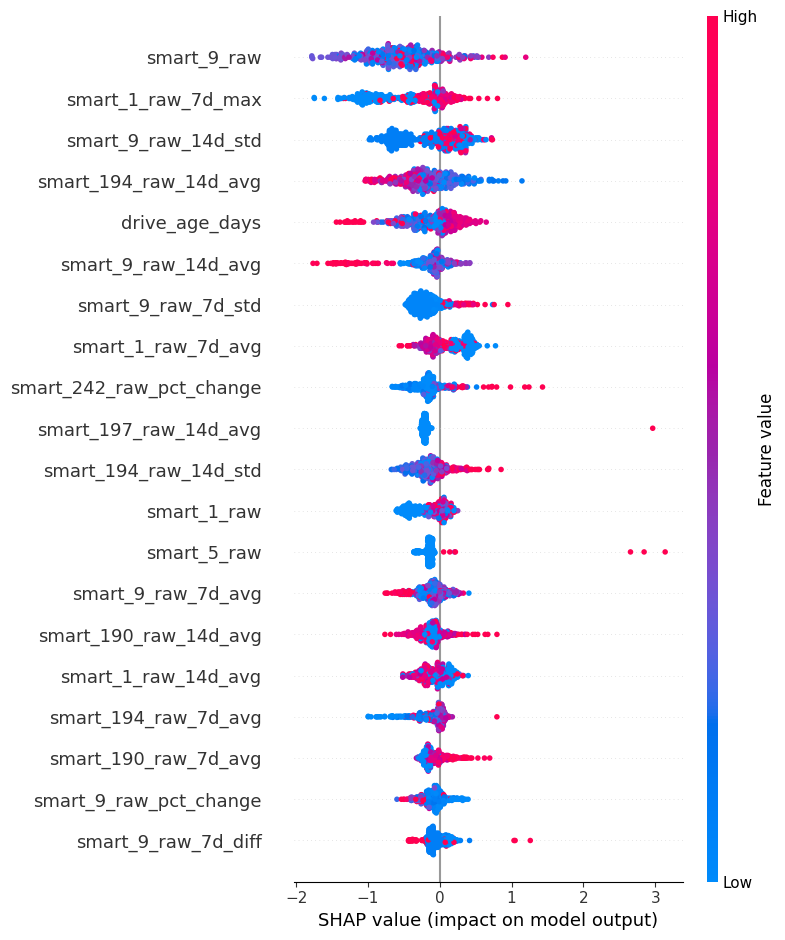

In [26]:
# Cell 17 - Explainable AI using SHAP

import shap

sample = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(model_bal)
shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample
)

In [27]:
import pickle

with open("disk_failure_model.pkl", "wb") as f:
    pickle.dump(model_bal, f)

with open("features.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Model Saved")
print("Features Saved")

Model Saved
Features Saved


In [29]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'features.pkl', 'disk_failure_model.pkl']
